In [1]:
import cudf as cf
import cupy as cp

import optuna
# Use native XGBoost Dask API instead of dask-ml
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

import plotly.express as px
from plotly.io import show

In [2]:
# Load the processed data
print("Loading csv data...")
df_dropped = cf.read_csv("./tmp/unfv_route_29_no_na_dropped.csv")
df_filled = cf.read_csv("./tmp/unfv_route_29_no_na_filled.csv")
print(f"Columns: {df_dropped.columns.tolist()}")

Loading csv data...
Columns: ['route', 'trip_id', 'stopid', 'hour', 'day_of_week', 'month', 'day_of_year', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'delay_seconds', 'Climate ID', 'Temp (°C)', 'Dew Point Temp (°C)', 'Rel Hum (%)', 'Wind Spd (km/h)', 'Visibility (km)', 'Stn Press (kPa)', 'Precip. Amount (mm)', 'bound', 'thrustreet', 'thrusteet_Dufferin St', 'thrusteet_Manitoba Dr', 'thrusteet_Nova Scotia Ave', 'thrusteet_Princes Blvd', "thrusteet_Princes' Blvd", "thrusteet_Princes' Gates Loop", 'thrusteet_Saskatchewan Rd', 'thrusteet_Wilson Ave', 'thrusteet_Wilson Station']


In [3]:
df_dropped.dtypes

route                            float64
trip_id                            int64
stopid                             int64
hour                             float64
day_of_week                      float64
month                            float64
day_of_year                      float64
hour_sin                         float64
hour_cos                         float64
day_of_week_sin                  float64
day_of_week_cos                  float64
delay_seconds                    float64
Climate ID                       float64
Temp (°C)                        float64
Dew Point Temp (°C)              float64
Rel Hum (%)                      float64
Wind Spd (km/h)                  float64
Visibility (km)                  float64
Stn Press (kPa)                  float64
Precip. Amount (mm)              float64
bound                              int64
thrustreet                        object
thrusteet_Dufferin St              int64
thrusteet_Manitoba Dr              int64
thrusteet_Nova S

In [4]:
df_dropped.isna().sum()

route                            0
trip_id                          0
stopid                           0
hour                             0
day_of_week                      0
month                            0
day_of_year                      0
hour_sin                         0
hour_cos                         0
day_of_week_sin                  0
day_of_week_cos                  0
delay_seconds                    0
Climate ID                       0
Temp (°C)                        0
Dew Point Temp (°C)              0
Rel Hum (%)                      0
Wind Spd (km/h)                  0
Visibility (km)                  0
Stn Press (kPa)                  0
Precip. Amount (mm)              0
bound                            0
thrustreet                       0
thrusteet_Dufferin St            0
thrusteet_Manitoba Dr            0
thrusteet_Nova Scotia Ave        0
thrusteet_Princes Blvd           0
thrusteet_Princes' Blvd          0
thrusteet_Princes' Gates Loop    0
thrusteet_Saskatchew

In [5]:
df_dropped['delay_seconds'].describe()

count    4.851443e+06
mean     3.508565e+01
std      7.771582e+02
min     -2.152100e+04
25%     -2.270000e+02
50%     -5.400000e+01
75%      1.448015e+02
max      3.779996e+04
Name: delay_seconds, dtype: float64

## EDA

Correlation Analysis

In [6]:
## correlation analysis of features with the target variable and show it in table
# remove thrusteet
df_corr = df_dropped.drop(columns=['thrustreet', 'route', 'trip_id']).to_pandas()  # Convert to pandas for correlation analysis
correlation_matrix = df_corr.corr(method='pearson')
target_correlation = correlation_matrix['delay_seconds'].drop('delay_seconds')  
print("Correlation of features with delay_seconds:")
print(target_correlation.sort_values(ascending=False))
# Visualize the correlation of features with the target variable using a bar chart
correlation_df = target_correlation.reset_index()
correlation_df.columns = ['Correlation', 'Feature']
fig = px.bar(correlation_df, x='Feature', y='Correlation', title='Correlation of Features with delay_seconds')
show(fig)

Correlation of features with delay_seconds:
hour_cos                         0.075351
Dew Point Temp (°C)              0.045032
day_of_week                      0.042780
day_of_year                      0.039958
Temp (°C)                        0.038502
month                            0.036424
hour                             0.030163
thrusteet_Princes' Gates Loop    0.015934
Rel Hum (%)                      0.012744
Visibility (km)                  0.008511
thrusteet_Princes' Blvd          0.006225
thrusteet_Dufferin St            0.001124
thrusteet_Manitoba Dr            0.000247
Precip. Amount (mm)              0.000207
thrusteet_Nova Scotia Ave       -0.000048
thrusteet_Wilson Ave            -0.000532
thrusteet_Saskatchewan Rd       -0.001524
thrusteet_Princes Blvd          -0.002413
day_of_week_sin                 -0.006600
Stn Press (kPa)                 -0.007691
stopid                          -0.008323
thrusteet_Wilson Station        -0.011282
bound                           

In [7]:
df_dropped.head()

,route,trip_id,stopid,hour,day_of_week,month,day_of_year,hour_sin,hour_cos,day_of_week_sin,...,thrustreet,thrusteet_Dufferin St,thrusteet_Manitoba Dr,thrusteet_Nova Scotia Ave,thrusteet_Princes Blvd,thrusteet_Princes' Blvd,thrusteet_Princes' Gates Loop,thrusteet_Saskatchewan Rd,thrusteet_Wilson Ave,thrusteet_Wilson Station
0,29.0,172354080,3880,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,Wilson Station,0,0,0,0,0,0,0,0,1
1,29.0,52553080,2728,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,Princes' Gates Loop,0,0,0,0,0,1,0,0,0
2,29.0,52553080,3993,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,Princes' Blvd,0,0,0,0,1,0,0,0,0
3,29.0,52553080,34800,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,Princes' Blvd,0,0,0,0,1,0,0,0,0
4,29.0,172354080,1361,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,Dufferin St,1,0,0,0,0,0,0,0,0


In [8]:
df_dropped.stopid.value_counts()

stopid
3880    99905
5325    54509
2031    54403
2695    54217
8627    54201
        ...  
871      7069
6427     7064
4853      601
4848      185
4144        1
Name: count, Length: 102, dtype: int64

### Top 10 stopid with highest data counts

In [9]:
# get top stopid with highest delay incidents
stopid_counts = df_dropped.groupby('stopid').size().reset_index(name='Count')
stopid_counts = stopid_counts.sort_values('Count', ascending=False)
top_routes = stopid_counts.head(10)
top_routes.stopid = top_routes.stopid.astype(str)  # Convert stopid to string for better visualization

fig = px.bar(top_routes, x='stopid', y='Count', title='Top 10 Stops with Highest data counts',
             color='Count', color_continuous_scale='viridis')
fig.update_layout(xaxis_title='stopid', yaxis_title='Count')

fig.show()

### Top 10 stop id with highest delay

In [10]:
# get top stopid with highest positive delay incidents
stopid_counts = df_dropped[df_dropped['delay_seconds'] > 0].groupby('stopid').size().reset_index(name='Count')
stopid_counts = stopid_counts.sort_values('Count', ascending=False)
top_routes = stopid_counts.head(10)
top_routes.stopid = top_routes.stopid.astype(str)  # Convert stopid to string for better visualization

fig = px.bar(top_routes, x='stopid', y='Count', title='Top 10 Stops with Highest positive delay incidents',
             color='Count', color_continuous_scale='viridis')
fig.update_layout(xaxis_title='stopid', yaxis_title='Count')

fig.show()

### Top 10 stop id with highest negative delay

In [11]:
# get top stopid with highest positive delay incidents
stopid_counts = df_dropped[df_dropped['delay_seconds'] < 0].groupby('stopid').size().reset_index(name='Count')
stopid_counts = stopid_counts.sort_values('Count', ascending=False)
top_routes = stopid_counts.head(10)
top_routes.stopid = top_routes.stopid.astype(str)  # Convert stopid to string for better visualization

fig = px.bar(top_routes, x='stopid', y='Count', title='Top 10 Stops with Highest negative delay incidents',
             color='Count', color_continuous_scale='viridis')
fig.update_layout(xaxis_title='stopid', yaxis_title='Count')

fig.show()

### Delay by thrustreet

In [12]:
# delay by thrustreet > 0 delay seconds
thrustreet_counts = df_dropped[df_dropped['delay_seconds'] > 0].groupby('thrustreet').size().reset_index(name='Count')
thrustreet_counts = thrustreet_counts.sort_values('Count', ascending=False)
top_thrustreets = thrustreet_counts.head(5)
top_thrustreets.thrustreet = top_thrustreets.thrustreet.astype(str
)  # Convert thrustreet to string for better visualization
fig = px.bar(top_thrustreets, x='thrustreet', y='Count', title='Top 5 Thrustreets with Highest positive delay incidents',
             color='Count', color_continuous_scale='viridis')
fig.update_layout(xaxis_title='thrustreet', yaxis_title='Count')
fig.show()


### Delay by hour

In [13]:
# delay by hour with > 0 delay seconds
hour_counts = df_dropped[df_dropped['delay_seconds'] > 0]['hour'].value_counts().sort_index()
hour_data = cf.DataFrame({'Hour': hour_counts.index, 'Count': hour_counts.values})
fig = px.bar(hour_data, x='Hour', y='Count', title='Delay Incidents by Hour of the Day', color='Hour')
fig.update_layout(xaxis_title='Hour of the Day', yaxis_title='Count')
fig.show()

### Delay by week

In [14]:
# delay by week with > 0 delay seconds
day_counts = df_dropped[df_dropped['delay_seconds'] > 0]['day_of_week'].value_counts().sort_index()
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
day_data = cf.DataFrame({'Day of the Week': day_order, 'Count': day_counts})

fig = px.bar(day_data, x='Day of the Week', y='Count', title='Delay Incidents by Day of the Week', color='Day of the Week')
fig.update_layout(xaxis_title='Day of the Week', yaxis_title='Count')

fig.show()

### Delay by month

In [15]:
# delay by month with > 0 delay seconds
month_counts = df_dropped[df_dropped['delay_seconds'] > 0]['month'].value_counts().sort_index()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

month_data = cf.DataFrame({'Month': month_order, 'Count': month_counts})

fig = px.pie(month_data, values='Count', names='Month', title='Frequency of Delays by Month',
             hole=0.4, color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_traces(textinfo='percent+label', pull=[0.1, 0, 0, 0, 0, 0])

fig.show()

In [16]:
print(f"\nFeature shape(Filled): {df_filled.shape[0]:,} rows x {df_filled.shape[1]} columns")


Feature shape(Filled): 5,025,282 rows x 31 columns


In [17]:
print(f"\nFeature shape(Dropped): {df_dropped.shape[0]:,} rows x {df_dropped.shape[1]} columns")


Feature shape(Dropped): 4,851,443 rows x 31 columns


## Dropped 

### Simple Model

In [18]:
cp.get_default_memory_pool().free_all_blocks()

In [19]:
df_dropped_X = df_dropped.drop(columns=['delay_seconds', 'route', 'trip_id', 'thrustreet'])
df_dropped_y = df_dropped['delay_seconds']

In [20]:
X_train_dropped, X_test_dropped, y_train_dropped, y_test_dropped = train_test_split(
    df_dropped_X,
    df_dropped_y,
    test_size=0.2,
    random_state=42
)

print(f"\nTrain size: {len(X_train_dropped):,}")
print(f"Test size: {len(X_test_dropped):,}")


Train size: 3,881,154
Test size: 970,289


In [21]:
X_train_dropped = X_train_dropped.to_cupy()
y_train_dropped = y_train_dropped.to_cupy()
X_test_dropped = X_test_dropped.to_cupy()
y_test_dropped = y_test_dropped.to_cupy()

In [22]:
# # Define Optuna objective function for hyperparameter tuning
import numpy as np
def objective(trial):
    """Optuna objective function to minimize RMSE using native XGBoost Dask API"""
    
    # Define hyperparameter search space
    params = {
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'device': 'cuda',
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 10_000,20_000, step=1000),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    
    n_samples = X_train_dropped.shape[0]
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    avg_r2_squares = np.zeros(kf.get_n_splits())
    
    # KFold.split only needs sample count — pass a range, no GPU→CPU data transfer
    for i, (train_index, val_index) in enumerate(kf.split(range(n_samples))):
        # Index cupy arrays directly with numpy indices
        dtrain = xgb.QuantileDMatrix(X_train_dropped[train_index], label=y_train_dropped[train_index])
        dval = xgb.QuantileDMatrix(X_train_dropped[val_index], label=y_train_dropped[val_index], ref=dtrain)

        model = xgb.train(params, dtrain, evals=[(dval, 'eval')], 
                      verbose_eval=False, early_stopping_rounds=100)
    
        # Make predictions (returns numpy array)
        y_pred = model.predict(dval)
    
        # Convert only the fold's labels to numpy for R2 score calculation
        y_fold = y_train_dropped[val_index].get()
        r2_square = r2_score(y_fold, y_pred)
        avg_r2_squares[i] = r2_square

    # Return average R2 square across folds
    return float(np.mean(avg_r2_squares))

print("Objective function defined with native XGBoost and Optuna GPU")

Objective function defined with native XGBoost and Optuna GPU


In [23]:
# Run Optuna hyperparameter optimization
print("Starting Optuna hyperparameter optimization...")
print("XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.")
print("This may take a while...\n")



# Create study
study_simple = optuna.create_study(
    direction='maximize',  # Maximize R2 square
    study_name='xgboost_delay_prediction',
    sampler=optuna.samplers.TPESampler(seed=42),
)

# Run optimization sequentially (XGBoost Dask handles parallelization internally)
n_trials = 50  # Total number of trials

print(f"Running {n_trials} trials...")

# Run sequential optimization - each trial uses Dask cluster efficiently
study_simple.optimize(objective, n_trials=n_trials, show_progress_bar=True)

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE!")
print("="*60)
print(f"\nBest trial: #{study_simple.best_trial.number}")
print(f"Best RMSE: {study_simple.best_value:.4f}")
print("\nBest hyperparameters:")
for key, value in study_simple.best_params.items():
    print(f"  {key}: {value}")

[I 2026-03-17 22:46:56,831] A new study created in memory with name: xgboost_delay_prediction


Starting Optuna hyperparameter optimization...
XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.
This may take a while...

Running 50 trials...


  0%|          | 0/50 [00:00<?, ?it/s]

/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:46:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:46:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:46:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:46:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-17 22:46:58,841] Trial 0 finished with value: 0.5456665877833459 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'n_estimators': 18000, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746}. Best is trial 0 with value: 0.5456665877833459.


...

[I 2026-03-17 22:48:43,185] Trial 47 finished with value: 0.6542272674017701 and parameters: {'max_depth': 9, 'learning_rate': 0.12498477830729372, 'n_estimators': 10000, 'subsample': 0.8517007898310468, 'colsample_bytree': 0.8398547086665542}. Best is trial 45 with value: 0.7472275727202998.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:48:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:48:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:48:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:48:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-17 22:48:45,843] Trial 48 finished with value: 0.7371454115186845 and parameters: {'max_depth': 10, 'learning_rate': 0.24518386596042147, 'n_estimators': 11000, 'subsample': 0.6369725684806261, 'colsample_bytree': 0.879202381886121}. Best is trial 45 with value: 0.7472275727202998.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:48:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:48:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:48:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:48:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-17 22:48:47,374] Trial 49 finished with value: 0.23863524629910743 and parameters: {'max_depth': 3, 'learning_rate': 0.29447085711946175, 'n_estimators': 11000, 'subsample': 0.6289717978506426, 'colsample_bytree': 0.8708894676805476}. Best is trial 45 with value: 0.7472275727202998.

OPTIMIZATION COMPLETE!

Best trial: #45
Best RMSE: 0.7472

Best hyperparameters:
  max_depth: 10
  learning_rate: 0.29320301235773083
  n_estimators: 13000
  subsample: 0.6827900943383748
  colsample_bytree: 0.8895376152999535


In [24]:
fig = optuna.visualization.plot_param_importances(study_simple)
show(fig)

In [25]:
study_simple.best_params

{'max_depth': 10,
 'learning_rate': 0.29320301235773083,
 'n_estimators': 13000,
 'subsample': 0.6827900943383748,
 'colsample_bytree': 0.8895376152999535}

In [26]:
cp.get_default_memory_pool().free_all_blocks()

In [27]:
# Train final model with best parameters using native XGBoost Dask API
print("Training final model with best hyperparameters...")
print("="*60)

# Get best parameters
best_params_simple = study_simple.best_params.copy()
best_params_clean = {k: v for k, v in best_params_simple.items() if k != 'num_boost_round'}
best_params_simple['objective'] = 'reg:squarederror'
best_params_simple['tree_method'] = 'hist'  # Required for Dask

# Create QuantileDMatrix for training
dtrain = xgb.DMatrix(X_train_dropped, y_train_dropped)

# Train final model using native Dask XGBoost
output_simple = xgb.train(
    best_params_simple,
    dtrain,
)

Training final model with best hyperparameters...


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning:

[22:48:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.




In [28]:
dtest = xgb.DMatrix(X_test_dropped)
y_pred_dropped = output_simple.predict(dtest)

In [29]:
rmse_simple = np.sqrt(mean_squared_error(y_test_dropped.get(), y_pred_dropped))
r2_simple = r2_score(y_test_dropped.get(), y_pred_dropped)
mae_simple = mean_absolute_error(y_test_dropped.get(), y_pred_dropped)
print("Final Model Performance on Test Set:")
print(f"  RMSE: {rmse_simple:.4f}")
print(f"  R²: {r2_simple:.4f}")
print(f"  MAE: {mae_simple:.4f}")

Final Model Performance on Test Set:
  RMSE: 394.8613
  R²: 0.7400
  MAE: 248.1431


In [30]:
output_simple.get_score(importance_type='gain')

{'f0': 23883454.0,
 'f1': 102643704.0,
 'f2': 168119360.0,
 'f3': 538102400.0,
 'f4': 306270464.0,
 'f5': 434383264.0,
 'f6': 165717680.0,
 'f7': 58838664.0,
 'f8': 142629440.0,
 'f10': 1444648192.0,
 'f11': 43657148.0,
 'f12': 234050928.0,
 'f13': 32084298.0,
 'f14': 26775790.0,
 'f15': 208209280.0,
 'f16': 41289408.0,
 'f17': 9115831.0,
 'f18': 4284980.0,
 'f20': 11065929.0,
 'f21': 9800487.0,
 'f22': 3918178.5,
 'f23': 12867709.0,
 'f24': 15733910.0,
 'f25': 598006.9375,
 'f26': 3620108.5}

In [31]:
output_simple.set_param({'device': 'cuda'})

In [33]:
import shap
shap_values = output_simple.predict(dtrain, pred_contribs=True)
explainer = shap.TreeExplainer(output_simple)
shap_values = explainer.shap_values(X_test_dropped)
feature_names = df_dropped_X.columns.tolist()

In [34]:
shap_values

array([[ 4.26780090e+01,  4.33841705e+01,  3.72054024e+01, ...,
        -1.33686196e-02, -1.14648337e-05,  3.81834768e-02],
       [-1.26432924e+01,  1.34332438e+01, -9.34690552e+01, ...,
         9.26430896e-03,  2.85437582e-05,  6.16482385e-02],
       [-6.47532043e+01, -8.85744400e+01,  4.86840172e+01, ...,
        -1.71838999e-02, -1.14648337e-05,  4.05855030e-02],
       ...,
       [-5.79085732e+00,  2.87121701e+00,  5.61917686e+01, ...,
        -1.37436045e-02,  1.01251084e-04,  8.49921778e-02],
       [-2.45257969e+01,  2.15653248e+01,  1.86837540e+01, ...,
        -9.01110936e-03, -1.14648337e-05,  4.37350385e-02],
       [-3.40869546e+00, -1.82887383e+01, -2.21588097e+01, ...,
        -3.27191763e-02,  1.15960756e-05,  1.00578763e-01]],
      shape=(970289, 27), dtype=float32)

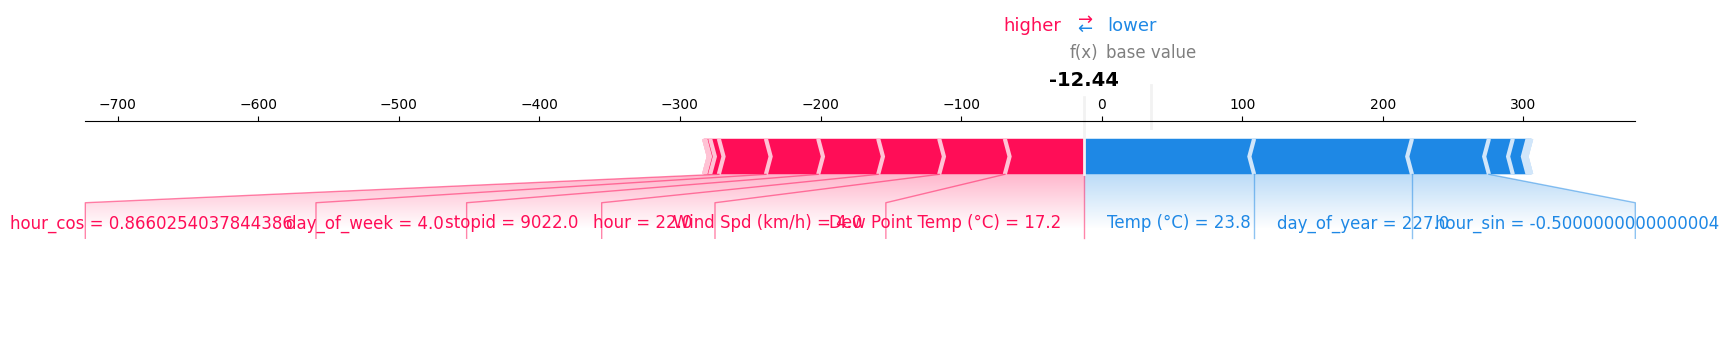

In [35]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0, :],
    X_train_dropped[0, :].get(),
    feature_names=feature_names,
    matplotlib=True,
)

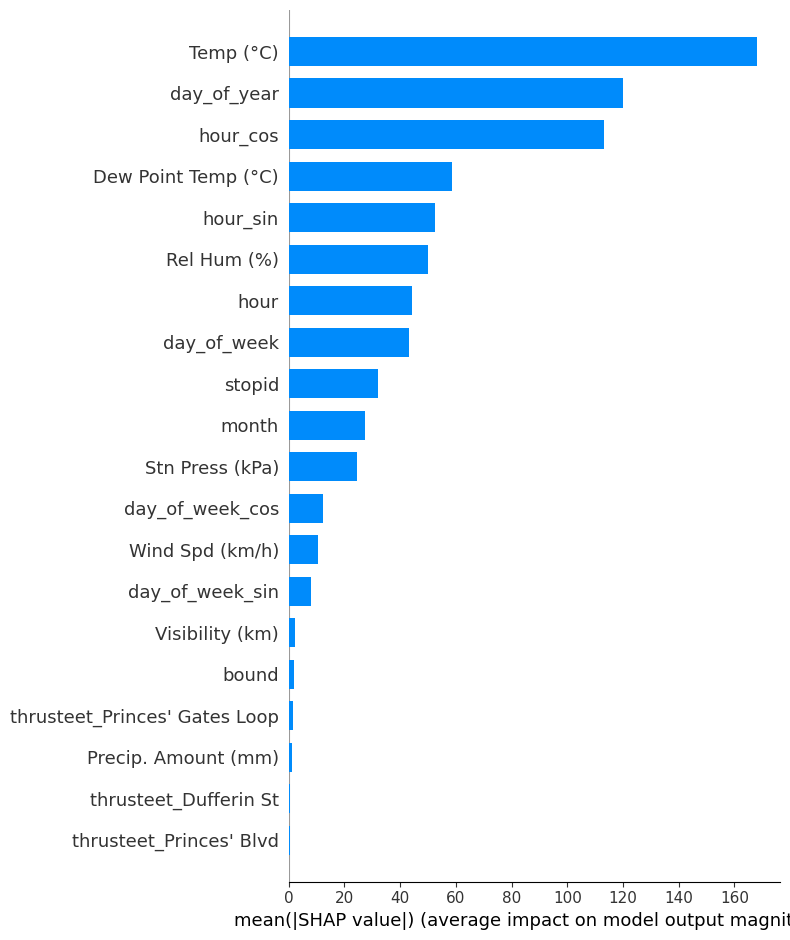

In [36]:
shap.summary_plot(shap_values, X_train_dropped, plot_type="bar", feature_names=feature_names)

### Complex Model

In [37]:
def objective(trial):
    """Optuna objective function to minimize RMSE using native XGBoost Dask API"""
    
    # Define hyperparameter search space
    params = {
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'device': 'cuda',
        # Use max_leaves instead of or alongside max_depth for more flexible trees
        'max_leaves': trial.suggest_int('max_leaves', 31, 512),
        'grow_policy': 'lossguide',  # Required for max_leaves to work with hist
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 10_000,15_000, step=1000),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        # L2 regularization on leaf weights (default=1)
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),

        # L1 regularization on leaf weights (default=0)
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),

        # Minimum loss reduction for further partitioning (default=0)
        'gamma': trial.suggest_float('gamma', 0, 5.0),

        # Minimum child weight — prevents overfitting to small leaf nodes
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'colsample_bynode': trial.suggest_float('colsample_bynode', 0.5, 1.0),
        
    }
    
    n_samples = X_train_dropped.shape[0]
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
        
    avg_r2_scores = np.zeros(kf.get_n_splits())
    
    # KFold.split only needs sample count — pass a range, no GPU→CPU data transfer
    for i, (train_index, val_index) in enumerate(kf.split(range(n_samples))):
        # Index cupy arrays directly with numpy indices
        dtrain = xgb.QuantileDMatrix(X_train_dropped[train_index], label=y_train_dropped[train_index])
        dval = xgb.QuantileDMatrix(X_train_dropped[val_index], label=y_train_dropped[val_index], ref=dtrain)

        model = xgb.train(params, dtrain, evals=[(dval, 'eval')], 
                      verbose_eval=False, early_stopping_rounds=100)
    
        # Make predictions (returns numpy array)
        y_pred = model.predict(dval)
    
        # Convert only the fold's labels to numpy for RMSE calculation
        y_fold = y_train_dropped[val_index].get()
        r2_scores = r2_score(y_fold, y_pred)
        avg_r2_scores[i] = r2_scores

        trial.report(np.mean(avg_r2_scores), i)
        if trial.should_prune():
            raise optuna.TrialPruned()
        
    # Return average R2 across folds
    return float(np.mean(avg_r2_scores))

print("Objective function defined with native XGBoost and Optuna GPU")

Objective function defined with native XGBoost and Optuna GPU


In [38]:
# Run Optuna hyperparameter optimization
print("Starting Optuna hyperparameter optimization...")
print("XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.")
print("This may take a while...\n")



# Create study with optuna
study_complex = optuna.create_study(
    direction='maximize',  # Maximize R2 square
    study_name='xgboost_delay_prediction',
    sampler=optuna.samplers.TPESampler(seed=42),
)

# Run optimization sequentially (XGBoost Dask handles parallelization internally)
n_trials = 50  # Total number of trials

print(f"Running {n_trials} trials...")

# Run sequential optimization - each trial uses Dask cluster efficiently
study_complex.optimize(objective, n_trials=n_trials, show_progress_bar=True)

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE!")
print("="*60)
print(f"\nBest trial: #{study_complex.best_trial.number}")
print(f"Best RMSE: {study_complex.best_value:.4f}")
print("\nBest hyperparameters:")
for key, value in study_complex.best_params.items():
    print(f"  {key}: {value}")

[I 2026-03-17 22:51:57,963] A new study created in memory with name: xgboost_delay_prediction


Starting Optuna hyperparameter optimization...
XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.
This may take a while...

Running 50 trials...


  0%|          | 0/50 [00:00<?, ?it/s]

/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:51:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:51:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:51:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:51:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-17 22:52:00,824] Trial 0 finished with value: 0.5417495816068632 and parameters: {'max_leaves': 211, 'learning_rate': 0.24517932047070642, 'n_estimators': 14000, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_lambda': 0.004207053950287938, 'reg_alpha': 0.0017073967431528124, 'gamma': 4.330880728874676, 'min_child_weight': 31, 'colsample_bylevel': 0.8540362888980227, 'colsample_bynode': 0.5102922471479012}. Best is trial 0 with value: 0.5417495816068632.


...

[I 2026-03-17 22:53:18,421] Trial 47 pruned. 


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:53:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.




[I 2026-03-17 22:53:19,146] Trial 48 pruned. 


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:53:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.




[I 2026-03-17 22:53:19,879] Trial 49 pruned. 

OPTIMIZATION COMPLETE!

Best trial: #42
Best RMSE: 0.6472

Best hyperparameters:
  max_leaves: 332
  learning_rate: 0.24517520900180625
  n_estimators: 13000
  subsample: 0.8198620362137857
  colsample_bytree: 0.9712493274633289
  reg_lambda: 0.9622779477991376
  reg_alpha: 0.02933137426277735
  gamma: 1.955507407972173
  min_child_weight: 25
  colsample_bylevel: 0.9124434490308926
  colsample_bynode: 0.9675175734597075


In [41]:
fig = optuna.visualization.plot_param_importances(study_complex)
show(fig)

In [42]:
study_complex.best_params

{'max_leaves': 332,
 'learning_rate': 0.24517520900180625,
 'n_estimators': 13000,
 'subsample': 0.8198620362137857,
 'colsample_bytree': 0.9712493274633289,
 'reg_lambda': 0.9622779477991376,
 'reg_alpha': 0.02933137426277735,
 'gamma': 1.955507407972173,
 'min_child_weight': 25,
 'colsample_bylevel': 0.9124434490308926,
 'colsample_bynode': 0.9675175734597075}

In [43]:
cp.get_default_memory_pool().free_all_blocks()

In [44]:
# Train final model with best parameters using native XGBoost Dask API
print("Training final model with best hyperparameters...")
print("="*60)

# Get best parameters
best_params_complex = study_complex.best_params.copy()
best_params_clean = {k: v for k, v in best_params_complex.items() if k != 'num_boost_round'}
best_params_complex['objective'] = 'reg:squarederror'
best_params_complex['tree_method'] = 'hist'  # Required for Dask

# Create QuantileDMatrix for training
dtrain = xgb.DMatrix(X_train_dropped, y_train_dropped)

# Train final model using native Dask XGBoost
output_complex = xgb.train(
    best_params_complex,
    dtrain,
)

Training final model with best hyperparameters...


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning:

[22:54:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.




In [45]:
dtest = xgb.DMatrix(X_test_dropped)
y_pred_dropped = output_complex.predict(dtest)

In [46]:
rmse_complex = np.sqrt(mean_squared_error(y_test_dropped.get(), y_pred_dropped))
r2_complex = r2_score(y_test_dropped.get(), y_pred_dropped)
mae_complex = mean_absolute_error(y_test_dropped.get(), y_pred_dropped)
print("Final Model Performance on Test Set:")
print(f"  RMSE: {rmse_complex:.4f}")
print(f"  R²: {r2_complex:.4f}")
print(f"  MAE: {mae_complex:.4f}")

Final Model Performance on Test Set:
  RMSE: 460.8220
  R²: 0.6459
  MAE: 276.7539


In [47]:
output_complex.set_param({'device': 'cuda'})

In [49]:
shap_values = output_complex.predict(dtrain, pred_contribs=True)
explainer = shap.TreeExplainer(output_complex)
shap_values = explainer.shap_values(X_test_dropped)
feature_names = df_dropped_X.columns.tolist()

In [50]:
shap_values

array([[ 1.70552864e+01, -9.07553101e+00,  1.49569931e+01, ...,
        -1.03515545e-02,  0.00000000e+00,  0.00000000e+00],
       [-9.68308640e+00,  1.01928978e+01, -4.23193779e+01, ...,
        -2.02220883e-02,  0.00000000e+00,  0.00000000e+00],
       [-7.24841356e+00,  1.82204590e+01,  1.02074599e+00, ...,
        -2.02220883e-02,  0.00000000e+00,  0.00000000e+00],
       ...,
       [-1.16841488e+01, -2.50052280e+01, -2.32324734e+01, ...,
        -2.02220883e-02,  0.00000000e+00,  0.00000000e+00],
       [-2.20285702e+01, -9.48068333e+00,  1.09613037e+01, ...,
        -1.03515545e-02,  0.00000000e+00,  0.00000000e+00],
       [-1.15390730e+01, -4.85458336e+01, -2.28119540e+00, ...,
        -2.02220883e-02,  0.00000000e+00,  0.00000000e+00]],
      shape=(970289, 27), dtype=float32)

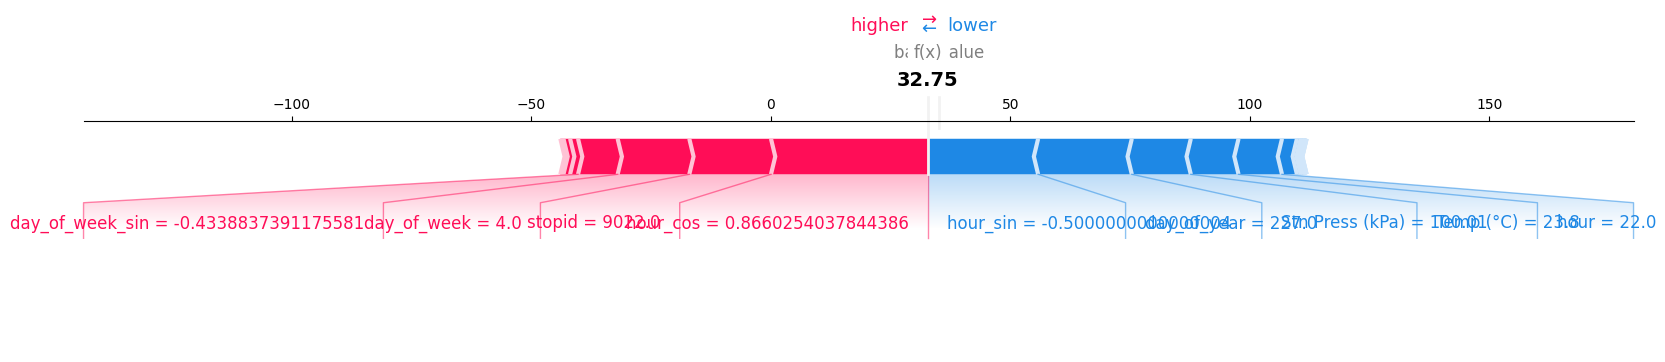

In [51]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0, :],
    X_train_dropped[0, :].get(),
    feature_names=feature_names,
    matplotlib=True,
)

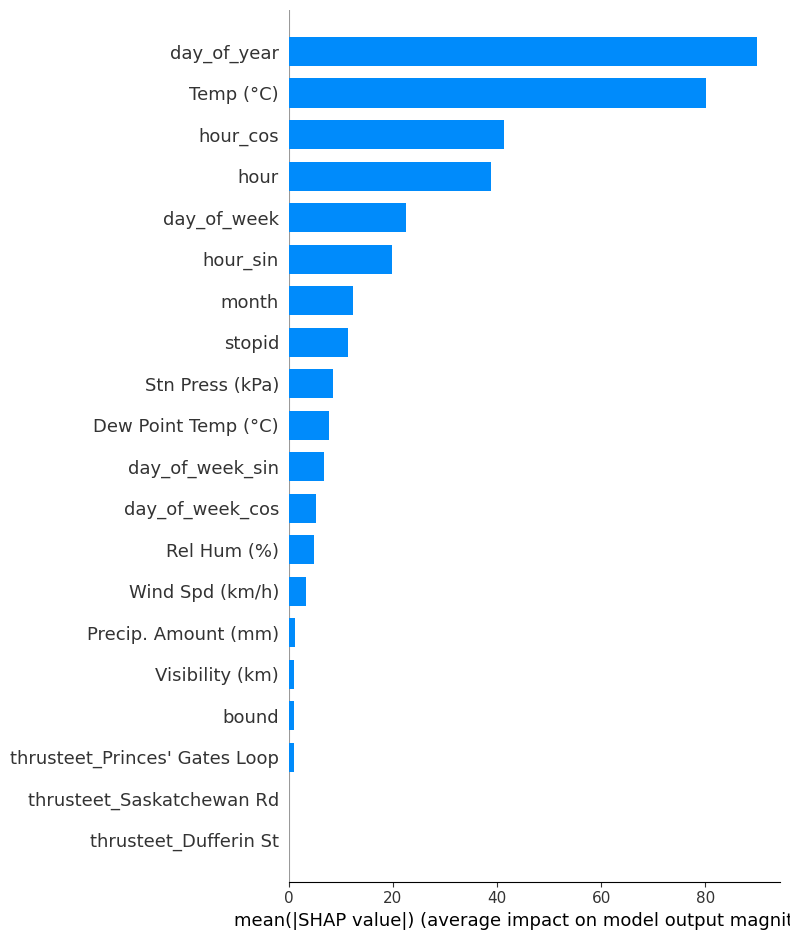

In [54]:
shap.summary_plot(shap_values, X_train_dropped, plot_type="bar", feature_names=feature_names)

### Complex vs Simple Model Chart

In [55]:
# now we make chart of complex vs simple, rmse and r2 in two figure using plotly
from plotly.subplots import make_subplots
import plotly.graph_objects as go

rmse = [rmse_simple, rmse_complex]
r2 = [r2_simple, r2_complex]
mae = [mae_simple, mae_complex]
models = ['Simple Model', 'Complex Model']

# using 1,2 subplot
fig = make_subplots(rows=1, cols=3, subplot_titles=('RMSE', 'R²', 'MAE'))
fig.add_trace(go.Bar(x=models, y=rmse), row=1, col=1)
fig.add_trace(go.Bar(x=models, y=r2), row=1, col=2)
fig.add_trace(go.Bar(x=models, y=mae), row=1, col=3)
fig.update_layout(title_text='Model Performance Comparison', showlegend=False)
fig.update_xaxes(title_text='Model', row=1, col=1)
fig.update_xaxes(title_text='Model', row=1, col=2)
fig.update_yaxes(title_text='RMSE', row=1, col=1)
fig.update_yaxes(title_text='R²', row=1, col=2)
fig.update_yaxes(title_text='MAE', row=1, col=3)

fig.show()

## Filled

In [57]:
cp.get_default_memory_pool().free_all_blocks()

In [61]:
X_train_filled, X_test_filled, y_train_filled, y_test_filled = train_test_split(
    df_filled.drop(columns=['delay_seconds', 'trip_id', 'route']),
    df_filled['delay_seconds'],
    test_size=0.2,
    random_state=42
)

In [62]:
X_train_filled = X_train_filled.to_cupy()
y_train_filled = y_train_filled.to_cupy()
X_test_filled = X_test_filled.to_cupy()
y_test_filled = y_test_filled.to_cupy()

In [63]:
# Define Optuna objective function for hyperparameter tuning
def objective(trial):
    """Optuna objective function to minimize RMSE using native XGBoost Dask API"""
    
    # Define hyperparameter search space
    params = {
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'device': 'cuda',
        # Use max_leaves instead of or alongside max_depth for more flexible trees
        'max_leaves': trial.suggest_int('max_leaves', 31, 512),
        'grow_policy': 'lossguide',  # Required for max_leaves to work with hist
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 10_000,15_000, step=1000),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        # L2 regularization on leaf weights (default=1)
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),

        # L1 regularization on leaf weights (default=0)
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),

        # Minimum loss reduction for further partitioning (default=0)
        'gamma': trial.suggest_float('gamma', 0, 5.0),

        # Minimum child weight — prevents overfitting to small leaf nodes
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'colsample_bynode': trial.suggest_float('colsample_bynode', 0.5, 1.0),
        
    }
    
    n_samples = X_train_filled.shape[0]
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
        
    avg_r2_scores = np.zeros(kf.get_n_splits())
    
    # KFold.split only needs sample count — pass a range, no GPU→CPU data transfer
    for i, (train_index, val_index) in enumerate(kf.split(range(n_samples))):
        # Index cupy arrays directly with numpy indices
        dtrain = xgb.QuantileDMatrix(X_train_filled[train_index], label=y_train_filled[train_index])
        dval = xgb.QuantileDMatrix(X_train_filled[val_index], label=y_train_filled[val_index], ref=dtrain)

        model = xgb.train(params, dtrain, evals=[(dval, 'eval')], 
                      verbose_eval=False, early_stopping_rounds=100)
    
        # Make predictions (returns numpy array)
        y_pred = model.predict(dval)
    
        # Convert only the fold's labels to numpy for RMSE calculation
        y_fold = y_train_filled[val_index].get()
        r2_scores = r2_score(y_fold, y_pred)
        avg_r2_scores[i] = r2_scores

        trial.report(np.mean(avg_r2_scores), i)
        if trial.should_prune():
            raise optuna.TrialPruned()
        
    # Return average R2 across folds
    return float(np.mean(avg_r2_scores))

print("Objective function defined with native XGBoost and Optuna GPU")

Objective function defined with native XGBoost and Optuna GPU


In [64]:
# Run Optuna hyperparameter optimization
print("Starting Optuna hyperparameter optimization...")
print("XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.")
print("This may take a while...\n")


# Create study with DaskStorage
study = optuna.create_study(
    direction='maximize',  # Maximize R2
    study_name='xgboost_delay_prediction',
    sampler=optuna.samplers.TPESampler(seed=42),
)

# Run optimization sequentially (XGBoost Dask handles parallelization internally)
n_trials = 30  # Total number of trials

print(f"Running {n_trials} trials...")

# Run sequential optimization - each trial uses Dask cluster efficiently
study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE!")
print("="*60)
print(f"\nBest trial: #{study.best_trial.number}")
print(f"Best RMSE: {study.best_value:.4f}")
print("\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-03-17 22:56:41,874] A new study created in memory with name: xgboost_delay_prediction


Starting Optuna hyperparameter optimization...
XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.
This may take a while...

Running 30 trials...


  0%|          | 0/30 [00:00<?, ?it/s]

/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:56:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:56:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:56:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:56:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-17 22:56:45,426] Trial 0 finished with value: 0.45960168596732903 and parameters: {'max_leaves': 211, 'learning_rate': 0.24517932047070642, 'n_estimators': 14000, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_lambda': 0.004207053950287938, 'reg_alpha': 0.0017073967431528124, 'gamma': 4.330880728874676, 'min_child_weight': 31, 'colsample_bylevel': 0.8540362888980227, 'colsample_bynode': 0.5102922471479012}. Best is trial 0 with value: 0.45960168596732903.


...

[I 2026-03-17 22:58:43,274] Trial 27 finished with value: 0.6103152139613641 and parameters: {'max_leaves': 161, 'learning_rate': 0.28536455357942664, 'n_estimators': 12000, 'subsample': 0.6839616917266772, 'colsample_bytree': 0.7624610977947756, 'reg_lambda': 0.15181592563411017, 'reg_alpha': 0.17823087943809127, 'gamma': 2.889849060578209, 'min_child_weight': 46, 'colsample_bylevel': 0.8319021740109016, 'colsample_bynode': 0.7579979396109574}. Best is trial 11 with value: 0.6300409407043476.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:58:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.




[I 2026-03-17 22:58:44,034] Trial 28 pruned. 


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:58:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:58:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:58:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[22:58:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-17 22:58:47,324] Trial 29 finished with value: 0.6038012884960822 and parameters: {'max_leaves': 180, 'learning_rate': 0.217357199397452, 'n_estimators': 14000, 'subsample': 0.8564578791136291, 'colsample_bytree': 0.9366133166319182, 'reg_lambda': 0.01636054798458119, 'reg_alpha': 0.004245345819804592, 'gamma': 1.9146713209188224, 'min_child_weight': 28, 'colsample_bylevel': 0.7637419108685606, 'colsample_bynode': 0.6160030721270633}. Best is trial 11 with value: 0.6300409407043476.

OPTIMIZATION COMPLETE!

Best trial: #11
Best RMSE: 0.6300

Best hyperparameters:
  max_leaves: 328
  learning_rate: 0.25049339886427907
  n_estimators: 14000
  subsample: 0.9831557287227188
  colsample_bytree: 0.97422475043257
  reg_lambda: 0.5748594743060452
  reg_alpha: 0.506356604725976
  gamma: 1.079180203564428
  min_child_weight: 41
  colsample_bylevel: 0.9559583616089686
  colsample_bynode: 0.9436930423192422


In [66]:
study.best_params

{'max_leaves': 328,
 'learning_rate': 0.25049339886427907,
 'n_estimators': 14000,
 'subsample': 0.9831557287227188,
 'colsample_bytree': 0.97422475043257,
 'reg_lambda': 0.5748594743060452,
 'reg_alpha': 0.506356604725976,
 'gamma': 1.079180203564428,
 'min_child_weight': 41,
 'colsample_bylevel': 0.9559583616089686,
 'colsample_bynode': 0.9436930423192422}

In [67]:
cp.get_default_memory_pool().free_all_blocks()

In [68]:
# Train final model with best parameters using native XGBoost Dask API
print("Training final model with best hyperparameters...")
print("="*60)

# Get best parameters
best_params = study.best_params.copy()
best_params = {k: v for k, v in best_params.items() if k != "num_boosted_rounds"}
best_params['objective'] = 'reg:squarederror'
best_params['tree_method'] = 'hist' 
best_params['device'] = 'cuda'

# Create QuantileDMatrix for training
dtrain = xgb.QuantileDMatrix(X_train_filled, y_train_filled)

output = xgb.train(
    best_params,
    dtrain,
)

Training final model with best hyperparameters...


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning:

[22:58:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.




In [69]:
dtest = xgb.QuantileDMatrix(X_test_filled)
y_pred_filled = output.predict(dtest)

In [71]:
rmse = np.sqrt(mean_squared_error(y_test_filled.get(), y_pred_filled))
r2 = r2_score(y_test_filled.get(), y_pred_filled)
mae_score = mean_absolute_error(y_test_filled.get(), y_pred_filled)
print("Final Model Performance on Test Set:")
print(f"  RMSE: {rmse:.4f}")
print(f"  R²: {r2:.4f}")
print(f"  MAE: {mae_score:.4f}")

Final Model Performance on Test Set:
  RMSE: 488.7361
  R²: 0.6052
  MAE: 280.6094
